### Step 1: Import and Initialize 

In [1]:
# import necessary libraries
from pyspark.sql import SparkSession
# initialize Spark Session
spark = SparkSession.builder.master('local').getOrCreate()

# read in csv to a spark dataframe
spark_df = spark.read.csv('./credit_card_default.csv', header='true', inferSchema='true')

### Step 2: Display and Print

In [2]:
# Display the first 5 records
spark_df.head(5)

[Row(ID=2, LIMIT_BAL=120000.0, SEX='Female', EDUCATION='College', MARRIAGE='Single', AGE=26, PAY_0=-1, PAY_2=2, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=2, BILL_AMT1=2682.0, BILL_AMT2=1725.0, BILL_AMT3=2682.0, BILL_AMT4=3272.0, BILL_AMT5=3455.0, BILL_AMT6=3261.0, PAY_AMT1=0.0, PAY_AMT2=1000.0, PAY_AMT3=1000.0, PAY_AMT4=1000.0, PAY_AMT5=0.0, PAY_AMT6=2000.0, default=1),
 Row(ID=3, LIMIT_BAL=90000.0, SEX='Female', EDUCATION='College', MARRIAGE='Single', AGE=34, PAY_0=0, PAY_2=0, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=0, BILL_AMT1=29239.0, BILL_AMT2=14027.0, BILL_AMT3=13559.0, BILL_AMT4=14331.0, BILL_AMT5=14948.0, BILL_AMT6=15549.0, PAY_AMT1=1518.0, PAY_AMT2=1500.0, PAY_AMT3=1000.0, PAY_AMT4=1000.0, PAY_AMT5=1000.0, PAY_AMT6=5000.0, default=0),
 Row(ID=4, LIMIT_BAL=50000.0, SEX='Female', EDUCATION='College', MARRIAGE='Married', AGE=37, PAY_0=0, PAY_2=0, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=0, BILL_AMT1=46990.0, BILL_AMT2=48233.0, BILL_AMT3=49291.0, BILL_AMT4=28314.0, BILL_AMT5=28959.0, BILL_AMT6=29547.0, P

In [3]:
spark_df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- LIMIT_BAL: double (nullable = true)
 |-- SEX: string (nullable = true)
 |-- EDUCATION: string (nullable = true)
 |-- MARRIAGE: string (nullable = true)
 |-- AGE: integer (nullable = true)
 |-- PAY_0: integer (nullable = true)
 |-- PAY_2: integer (nullable = true)
 |-- PAY_3: integer (nullable = true)
 |-- PAY_4: integer (nullable = true)
 |-- PAY_5: integer (nullable = true)
 |-- PAY_6: integer (nullable = true)
 |-- BILL_AMT1: double (nullable = true)
 |-- BILL_AMT2: double (nullable = true)
 |-- BILL_AMT3: double (nullable = true)
 |-- BILL_AMT4: double (nullable = true)
 |-- BILL_AMT5: double (nullable = true)
 |-- BILL_AMT6: double (nullable = true)
 |-- PAY_AMT1: double (nullable = true)
 |-- PAY_AMT2: double (nullable = true)
 |-- PAY_AMT3: double (nullable = true)
 |-- PAY_AMT4: double (nullable = true)
 |-- PAY_AMT5: double (nullable = true)
 |-- PAY_AMT6: double (nullable = true)
 |-- default: integer (nullable = true)



### Step 3: Select and show all distinct categories

In [4]:
spark_df.select(['SEX', 'EDUCATION', 'MARRIAGE']).distinct().show()

+------+-----------+--------+
|   SEX|  EDUCATION|MARRIAGE|
+------+-----------+--------+
|Female|          6| Married|
|  Male|          5|  Single|
|Female|    College| Married|
|  Male|   Graduate|  Single|
|Female|      Other| Married|
|Female|    College|   Other|
|  Male|    College|   Other|
|  Male|   Graduate|       0|
|  Male|          5|   Other|
|  Male|      Other| Married|
|  Male|High School|   Other|
|Female|          5| Married|
|Female|    College|  Single|
|Female|   Graduate|  Single|
|  Male|          5| Married|
|  Male|   Graduate|   Other|
|Female|High School|   Other|
|Female|          5|  Single|
|Female|   Graduate| Married|
|Female|High School| Married|
+------+-----------+--------+
only showing top 20 rows



### Step 4: Barplots of EDUCATION and MARRIAGE

+-----------+-----+
|  EDUCATION|count|
+-----------+-----+
|High School| 4917|
|          0|   14|
|          5|  280|
|          6|   51|
|      Other|  123|
|   Graduate|10585|
|    College|14029|
+-----------+-----+



<Axes: xlabel='EDUCATION'>

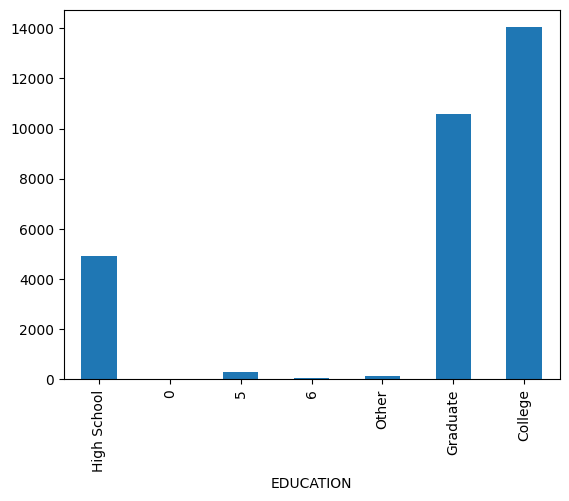

In [ ]:
# Create bar plot of EDUCATION
# First, aggregate data
education_counts = spark_df.groupBy('EDUCATION').count()
education_counts.show()

# Convert to Pandas for plotting
education_counts.toPandas().plot(kind='bar', x='EDUCATION', y='count', legend=False)

+--------+-----+
|MARRIAGE|count|
+--------+-----+
|       0|   54|
|   Other|  323|
| Married|13658|
|  Single|15964|
+--------+-----+



<Axes: xlabel='MARRIAGE'>

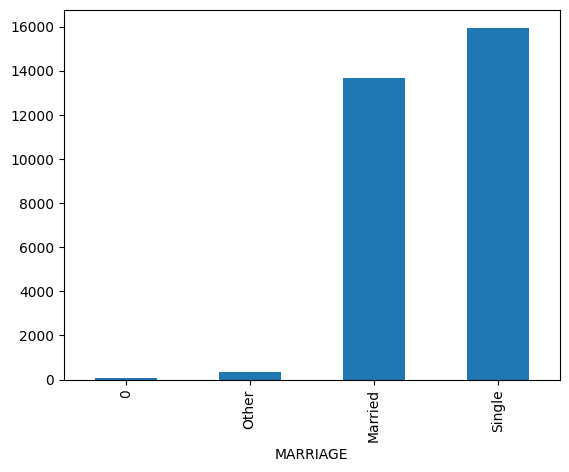

In [6]:
# Create bar plot of MARRIAGE
marriage_counts = spark_df.groupBy('MARRIAGE').count()
marriage_counts.show()

marriage_counts.toPandas().plot(kind='bar', x='MARRIAGE', y='count', legend=False)

### Step 5: Bin EDUCATION and MARRIAGE

In [7]:
# Bin EDUCATION categories
from pyspark.sql import functions as F

df_education_binned = spark_df.withColumn('EDUCATION',
                                          F.when(spark_df['EDUCATION'] == '0', 'Other')\
                                          .when(spark_df['EDUCATION'] == '5', 'Other')\
                                          .when(spark_df['EDUCATION'] == '6', 'Other')\
                                          .otherwise(spark_df['EDUCATION'])
                                         )

# Bin MARRIAGE categories
df_all_binned = df_education_binned.withColumn('MARRIAGE',
                                               F.when(df_education_binned['MARRIAGE'] == '0', 'Other')\
                                               .otherwise(df_education_binned['MARRIAGE'])
                                              )

# Select and show all distinct categories for EDUCATION and MARRIAGE after binning
df_all_binned.select(['EDUCATION']).distinct().show()
df_all_binned.select(['MARRIAGE']).distinct().show()

+-----------+
|  EDUCATION|
+-----------+
|High School|
|      Other|
|   Graduate|
|    College|
+-----------+

+--------+
|MARRIAGE|
+--------+
|   Other|
| Married|
|  Single|
+--------+



### Step 6: Plot the bins

+-----------+-----+
|  EDUCATION|count|
+-----------+-----+
|High School| 4917|
|      Other|  468|
|   Graduate|10585|
|    College|14029|
+-----------+-----+



<Axes: xlabel='EDUCATION'>

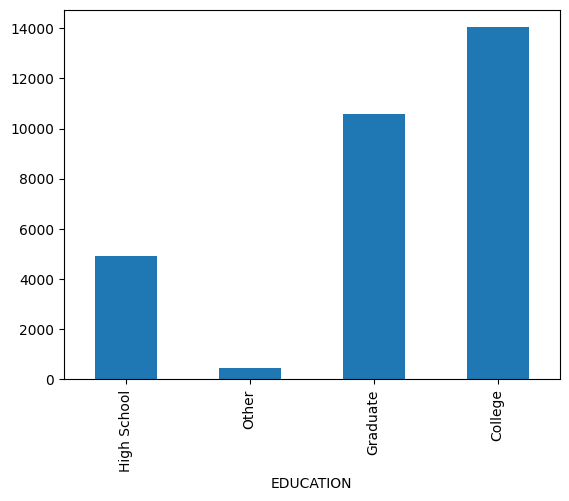

In [8]:
education_counts = df_all_binned.groupBy('EDUCATION').count()
education_counts.show()

# Convert to Pandas for plotting
education_counts.toPandas().plot(kind='bar', x='EDUCATION', y='count', legend=False)

+--------+-----+
|MARRIAGE|count|
+--------+-----+
|   Other|  377|
| Married|13658|
|  Single|15964|
+--------+-----+



<Axes: xlabel='MARRIAGE'>

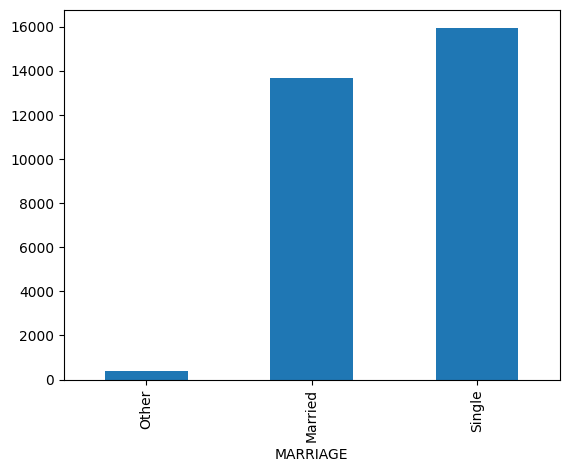

In [9]:
# Create bar plot of MARRIAGE
marriage_counts = df_all_binned.groupBy('MARRIAGE').count()
marriage_counts.show()

marriage_counts.toPandas().plot(kind='bar', x='MARRIAGE', y='count', legend=False)

### Step 7: Barcharts for (non-)defaults

+-------+-----+
|default|count|
+-------+-----+
|      0|23364|
|      1| 6635|
+-------+-----+



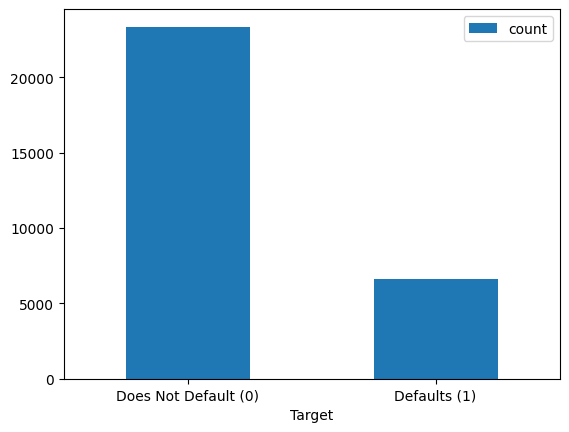

In [10]:
import matplotlib.pyplot as plt

# Group and aggregate target data
# Group and aggregate target data
target_cats = df_all_binned.groupBy('default').count().orderBy('default')
target_cats.show()

# Plot target data
fig, ax = plt.subplots()
target_cats.toPandas().plot(x='default', y='count', kind='bar', ax=ax, rot=0)
ax.set_xlabel("Target")
ax.set_xticklabels(['Does Not Default (0)','Defaults (1)']);

### Step 8: Group by DEFAULT and SEX

+-------+------+-----+
|default|   SEX|count|
+-------+------+-----+
|      0|Female|14349|
|      0|  Male| 9015|
|      1|Female| 3762|
|      1|  Male| 2873|
+-------+------+-----+



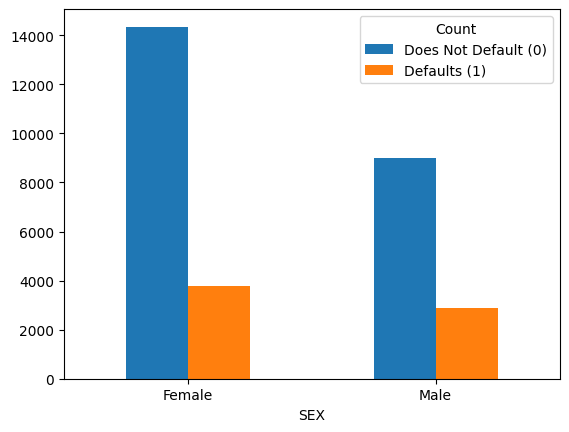

In [11]:
# Group and aggregate target and sex data
target_by_sex = df_all_binned.groupBy(['default', 'SEX']).count().orderBy(['default', 'SEX'])
target_by_sex.show()

# Plot target and sex data
fig, ax = plt.subplots()

target_by_sex.toPandas().pivot(index='SEX', columns='default')\
               .plot(kind='bar', ax=ax, rot=0)

ax.legend(title="Count", labels=['Does Not Default (0)','Defaults (1)']);